# Mentallama QLORA 7B V3
__What__ <br>
Updated version of QLORA 7B V2. Changes are based on QLORA 7B V3, where qa_preprocess has been updated to optimize the structure, as well as changing the prompt.

__Usage__ <br>
Compare with LORA 7B and Mentallama


__Conclusion (if any)__ <br>
Final version used for the report

## Imports & setups

In [ ]:
#Installs
!pip install -q -U transformers
!pip install -q -U datasets
!pip install -q -U evaluate
!pip install -q -U tokenizers
!pip install -q -U "huggingface_hub[hf_transfer]<1.0"
!pip install -q -U bitsandbytes




In [ ]:
#Imports
import os
import time
import gc
import json
import glob

from google.colab import drive
from typing import Literal


import torch
import evaluate
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, LlamaTokenizer, LlamaForCausalLM, Trainer, TrainingArguments, Gemma3ForCausalLM, DataCollatorForLanguageModeling
import torch.optim as optim
from datasets import load_dataset, Dataset, DatasetDict, Features, Value
from peft import LoraConfig, get_peft_model, TaskType, PeftModel, prepare_model_for_kbit_training

In [ ]:
#Constants
WORKING_DIR = "/content/drive/MyDrive/HF"
MODELS_DIR = WORKING_DIR + "/models/"

In [ ]:
#Download setup
drive.mount('/content/drive')
HF_HUB_ENABLE_HF_TRANSFER=1
os.chdir(WORKING_DIR)

Mounted at /content/drive


In [ ]:
SEED = 42

## Helper functions

In [ ]:
def qa_preprocess(
    example,
    tokenizer,
    model_family="llama3",
    system_prompt="",
    user_template="{query}",
    answer_template="{answer}",
    max_length=2048,
):
    """
    Preprocess a single QA example using either LLaMA 2 or LLaMA 3 chat templates.

    Expects example to contain:
      - example["query"]
      - example["answer"]
    """

    q = example["query"]
    a = example["answer"]

    # Fill templates
    user_text = user_template.format(query=q, answer=a)
    answer_text = answer_template.format(query=q, answer=a)

    # ============================================
    # =============== LLaMA 3 =====================
    # ============================================
    if model_family == "llama3":

        # ---- Build chat messages ----
        messages = []
        if system_prompt:
            messages.append({"role": "system", "content": system_prompt})
        messages.append({"role": "user", "content": user_text})
        messages.append({"role": "assistant", "content": answer_text})

        # ---- Full formatted text (system + user + assistant) ----
        full_text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
        )

        # ---- Prefix text (system + user only, no assistant) ----
        prefix_text = tokenizer.apply_chat_template(
            messages[:-1],   # everything except assistant
            tokenize=False,
            add_generation_prompt=False,
        )

        # Tokenize prefix to get its length
        prefix_tokens = tokenizer(
            prefix_text,
            truncation=True,
            max_length=max_length,
            add_special_tokens=False,
        )
        prefix_len = len(prefix_tokens["input_ids"])

        # Tokenize full sequence
        tokens = tokenizer(
            full_text,
            truncation=True,
            max_length=max_length,
            add_special_tokens=False,
        )

        input_ids = tokens["input_ids"]
        # Mask everything before assistant answer
        labels = [-100] * min(prefix_len, len(input_ids)) + input_ids[prefix_len:]
        tokens["labels"] = labels

        return tokens

    # ============================================
    # =============== LLaMA 2 =====================
    # ============================================
    elif model_family == "llama2":

        # System block (LLaMA 2 style)
        if system_prompt:
            sys_block = f"<<SYS>>\n{system_prompt}\n<</SYS>>\n\n"
        else:
            sys_block = ""

        # Prompt without assistant answer
        prompt_no_answer = f"<s>[INST] {sys_block}{user_text} [/INST]"

        # Full prompt including assistant
        full_text = f"{prompt_no_answer} {answer_text}</s>"

        # Tokenize prefix (user/system only)
        prefix_tokens = tokenizer(
            prompt_no_answer,
            truncation=True,
            max_length=max_length,
            add_special_tokens=False,
        )
        prefix_len = len(prefix_tokens["input_ids"])

        # Tokenize full sequence
        tokens = tokenizer(
            full_text,
            truncation=True,
            max_length=max_length,
            add_special_tokens=False,
        )

        input_ids = tokens["input_ids"]
        labels = [-100] * min(prefix_len, len(input_ids)) + input_ids[prefix_len:]
        tokens["labels"] = labels

        return tokens

    else:
        raise ValueError(f"Unknown model_family: {model_family}")

In [ ]:
def model_train_check(model, tokenizer, text = None, num_samples = 1, args = None):
    """
      Verify a model can be trained as expected, and also check how long the training took.
      Input:
        model: Model to test
        text: Text data to test. If not we'll use sample
        num_sample: Number of sample text. If it's more than one, we repeat the same text multiple times.
        args: arguments used for training. If not the function will decide.

      Output:
    """
    if text is None:
      text = """Consider this post: ""How to avoid a relapse? I've been having a particularly rough year; I attempted suicide, the love of my life left me, I failed my year at university, I've been physically assaulted, I've been sexually assaulted and today my grandfather died. I feel like I'm running on empty and doing the bare minimum to survive for myself while trying to be a rock to others. My emotional resilience has been wiped out. I feel ""okay"" but I've felt like this in the past and it has turned out that I've just been lying to myself and making things worse. Any advice on how to manage/process my emotions? Or just how to better understand myself?"" Question: Does the poster suffer from depression?", "Yes, the poster suffers from depression. Reasoning: The post displays a significant amount of emotional distress, including experiencing a suicide attempt, multiple traumatic events, and the recent death of a family member. The poster describes feeling emotionally depleted, struggling to cope, and questioning their ability to understand and manage their own emotions. This level of emotional pain, trauma, and self-doubt aligns with symptoms commonly associated with very severe depression. The poster's request for advice on managing emotions and understanding oneself further suggests a need for additional support and resources to address their mental health."""

    data = [text for x in range(num_samples)]

    features = Features({
        "text": Value("string")
    })

    ds = Dataset.from_dict(
        {"text": data},
        features=features
    )


    #Prepare tokenized text & collator

    tok_ds = ds.map(tok_fn, batched=True, remove_columns=ds.column_names, fn_kwargs={"tokenizer": tokenizer} )
    collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)


    if args is None:
      args = TrainingArguments(
        output_dir="out",
        per_device_train_batch_size=4,
        gradient_accumulation_steps=8,
        learning_rate=2e-4,
        num_train_epochs=1,
        fp16=True,
        logging_steps=10,
        save_steps=50,
        max_grad_norm=1.0,
        report_to="none")

    start_time = time.time()
    trainer = Trainer(model=model, args=args, train_dataset=tok_ds,
        data_collator=collator)
    trainer.train()
    end_time = time.time()
    duration = end_time - start_time
    print(f"Training took {duration:.4f} seconds for {num_samples} sample(s), {(duration / num_samples):.4f} samples/sec")

def tok_fn(t,tokenizer):
      return tokenizer(t["text"], truncation=True, max_length=1024)


## Prepare datasets

In [ ]:
train_ds = None
val_ds = None

In [ ]:
!echo "{target_folder}/*" >> {temp_repo}/.git/info/sparse-checkout

/bin/bash: line 1: {temp_repo}/.git/info/sparse-checkout: No such file or directory


In [ ]:
#Download training data for MentalLLaMA
#TODO: Cache the data into Google drive
temp_repo= 'data'
target_folder = 'train_data/instruction_data'

!git init {temp_repo}
!cd {temp_repo} && git remote add -f origin https://github.com/SteveKGYang/MentalLLaMA.git
!cd {temp_repo} && git config core.sparseCheckout true
!echo "{target_folder}/*" >> {temp_repo}/.git/info/sparse-checkout
!cd {temp_repo} && git pull origin main

Reinitialized existing Git repository in /content/drive/MyDrive/HF/data/.git/
error: remote origin already exists.
From https://github.com/SteveKGYang/MentalLLaMA
 * branch            main       -> FETCH_HEAD
Already up to date.


In [ ]:
#Put training data into datasets (train & val)
BASE_DIR = f"{WORKING_DIR}/{temp_repo}/{target_folder}/"
csv_files = sorted(glob.glob(os.path.join(BASE_DIR, "**/*train.csv"), recursive=True))
print(f"Train: {len(csv_files)} files")
ds = load_dataset("csv",data_files={"train": csv_files})
train_ds = ds["train"]
train_ds = train_ds.rename_columns({"gpt-3.5-turbo":"answer"})

csv_files = sorted(glob.glob(os.path.join(BASE_DIR, "**/*val.csv"), recursive=True))
print(f"Val: {len(csv_files)} files")
ds = load_dataset("csv",data_files={"train": csv_files})
val_ds = ds["train"]
val_ds = val_ds.rename_columns({"gpt-3.5-turbo":"answer"})


Train: 5 files


Generating train split: 0 examples [00:00, ? examples/s]

Val: 5 files


Generating train split: 0 examples [00:00, ? examples/s]

## Load llama & configure

In [ ]:
MODEL_NAME = 'Llama-2-7b-chat-hf'
HF_MODEL_PATH = "meta-llama/Llama-2-7b-chat-hf"
MODEL_DIR = os.path.join(MODELS_DIR, MODEL_NAME)


bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)



try:
  print("Load model from Google drive if the model data exists. ")
  tokenizer = LlamaTokenizer.from_pretrained(MODEL_DIR)
  base_model = LlamaForCausalLM.from_pretrained(MODEL_DIR,
                                          device_map='auto',
                                          attn_implementation="eager",
                                          quantization_config=bnb_config)
except Exception as e:
  print(f"Tokenizer or model load from GDrive failed: {e}")
  print("Downloading them from hugging face instead")
  tokenizer = LlamaTokenizer.from_pretrained(HF_MODEL_PATH)
  base_model = LlamaForCausalLM.from_pretrained(HF_MODEL_PATH,
                                          device_map='auto',
                                          attn_implementation="eager",
                                          quantization_config=bnb_config)
  print("Saving them to Google drive")
  base_model.save_pretrained(MODEL_DIR)
  tokenizer.save_pretrained(MODEL_DIR)

Load model from Google drive if the model data exists. 


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
base_model = prepare_model_for_kbit_training(base_model)
base_model.config.use_cache = False   # important for training




lora = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"]
#    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj"]
    )

model = get_peft_model(base_model, lora)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id

In [ ]:
model_train_check(model, tokenizer, num_samples=10)

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss


Training took 20.2526 seconds for 10 sample(s), 2.0253 samples/sec


## Fine tune Llama to create Mentallama variant

In [ ]:
MODEL_NAME = 'MentaLLaMA-QLORA-7B-hf-3'
OUTPUT_DIR = os.path.join(MODELS_DIR, MODEL_NAME)


system_prompt = """
You are a mental-health text classification assistant.

Your task:
1. Read user’s post and answer a mental-health–related question.
2. Your output MUST follow this exact format and nothing else:

   Line 1: Answer: <one sentence answer>
   Line 2: Reasoning: <short, non-repetitive explanation>

3. The Answer must include a label (e.g., “Yes”, “No”, “Work”, “Family”, “Depression”, etc.).
4. The reasoning must be directly grounded in the content of the post.
5. Do not speculate beyond what is written.
6. Do not repeat sentences, ideas, or explanations.
7. Reasoning must be concise and under 200 words.
8. Never start your answer with “Reasoning:” or any explanation. Always start with “Answer:”.
"""

train_ds_tok = train_ds.map(
    lambda ex: qa_preprocess(
        ex,
        tokenizer,
        model_family="llama3",
        system_prompt=system_prompt,
        user_template="{query}\n",
        answer_template="{answer}",
    ),
    batched=False,
    remove_columns=train_ds.column_names
)

val_ds_tok = val_ds.map(
    lambda ex: qa_preprocess(
        ex,
        tokenizer,
        model_family="llama3",
        system_prompt=system_prompt,
        user_template="{query}\n",
        answer_template="{answer}",
    ),
    batched=False,
    remove_columns=train_ds.column_names
)

from transformers import DataCollatorForSeq2Seq
collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    label_pad_token_id=-100,
    pad_to_multiple_of=8,
    padding = 'longest'
)
args =  TrainingArguments(
        output_dir=OUTPUT_DIR,
        per_device_train_batch_size=8,
        gradient_accumulation_steps=16,
        learning_rate=2e-5,
        num_train_epochs=10,
        warmup_ratio=0.03,
        fp16=True,
        logging_steps=50,
        save_strategy="epoch",
        eval_strategy="steps",
        max_grad_norm=1.0,
        report_to="none",
        optim="adamw_torch",
        eval_steps=50,
        metric_for_best_model="eval_loss",
        group_by_length = True
        )
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds_tok,
    eval_dataset=val_ds_tok,
    data_collator = collator
    )

Map:   0%|          | 0/29073 [00:00<?, ? examples/s]

Map:   0%|          | 0/3831 [00:00<?, ? examples/s]

In [ ]:
try:
  trainer.train(resume_from_checkpoint = True)
except Exception as e:
  print("Caught a ValueError:", e)
  print("Attempting to train without setting resume_from_checkpoint")
  trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
1850,0.522600,0.544674
1900,0.486800,0.543642
1950,0.485000,0.543397
2000,0.488400,0.542953
2050,0.467600,0.542792
2100,0.482900,0.542326
2150,0.483500,0.541941
2200,0.483800,0.542153
2250,0.482400,0.541667


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


#Training results

In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

FINAL_TRAINING_CHECKPOINT = 'checkpoint-2280'
MODEL_NAME = 'MentaLLaMA-QLORA-7B-hf-3'

In [ ]:
#Get the json file that stores the train history
results_path = f"{MODELS_DIR}/{MODEL_NAME}/{FINAL_TRAINING_CHECKPOINT}/trainer_state.json"
with open(results_path, 'r') as file:
    results_json = json.load(file)

#Store as pandas
history = pd.DataFrame(results_json['log_history'])

In [ ]:
#Separate train loss and val/eval loss rows
history_train = history.loc[history['eval_loss'].isna()]
history_val = history.loc[~history['eval_loss'].isna()]

#Remove unnecessary columns before merging
history_train = history_train.loc[:, ~history_train.columns.str.contains("eval")]
history_val = history_val.iloc[:,4:]

#Merge train and eval data
history_merged = history_train.merge(history_val, on='step')

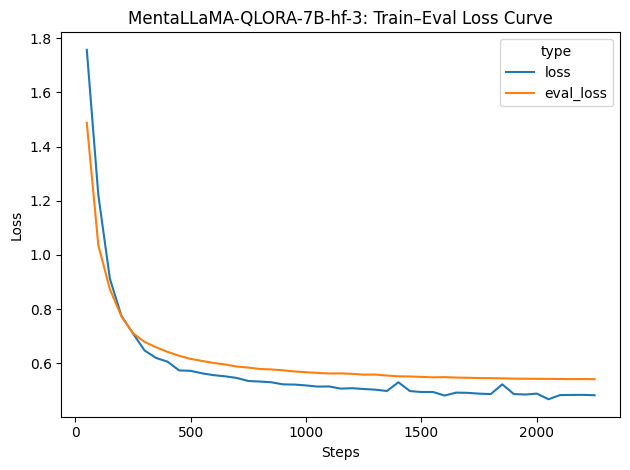

In [ ]:

#Convert to long prior to visualizing
history_long = history_merged.melt(id_vars="step", value_vars=["loss", "eval_loss"], var_name="type", value_name="loss_val")


ax = sns.lineplot(data=history_long,x="step",y="loss_val",hue="type")
ax.set_title(f"{MODEL_NAME}: Train–Eval Loss Curve")
ax.set_xlabel("Steps")
ax.set_ylabel("Loss")
plt.tight_layout()
plt.show()